In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# -------- INPUT --------
stock = "IBM"   # change this to any stock
years = 5

# -------- DATE RANGE --------
end_date = datetime.today()
start_date = end_date - timedelta(days=years*365)

# -------- DOWNLOAD DATA --------
data = yf.download(stock, start=start_date, end=end_date)

# -------- KEEP ONLY REQUIRED COLUMNS --------
df = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.reset_index(inplace=True)
df["Time"] = "17:00:00"

# -------- REORDER COLUMNS --------
df = df[["Date", "Time", "Open", "High", "Low", "Close", "Volume"]]

# -------- SAVE CSV --------
filename = f"{stock}_5years_timeseries.csv"
df.to_csv(filename, index=False)

print(f"CSV file '{filename}' created successfully!")

/tmp/ipykernel_12572/2886810147.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

CSV file 'IBM_5years_timeseries.csv' created successfully!


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy.stats import zscore
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'font.size':        9,
    'axes.titlesize':   11,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#2e3250',
    'figure.dpi':       130,
})

ACCENT  = '#58a6ff'
GREEN   = '#3fb950'
ORANGE  = '#d29922'
RED     = '#f85149'
PURPLE  = '#bc8cff'
CLUSTER_COLORS = ['#58a6ff', '#3fb950', '#d29922', '#f85149', '#bc8cff', '#39d3f2']

Data Loading & Preprocessing

In [4]:
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath, skiprows=1, header=None)
    df.columns = ['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume']

    df['Date']   = pd.to_datetime(df['Date'])
    df['Open']   = pd.to_numeric(df['Open'],   errors='coerce')
    df['High']   = pd.to_numeric(df['High'],   errors='coerce')
    df['Low']    = pd.to_numeric(df['Low'],    errors='coerce')
    df['Close']  = pd.to_numeric(df['Close'],  errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

    df.dropna(subset=['Close'], inplace=True)
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    df.set_index('Date', inplace=True)

    df['Log_Return']   = np.log(df['Close'] / df['Close'].shift(1))
    df['Daily_Return'] = df['Close'].pct_change()
    df['SMA_20']       = df['Close'].rolling(20).mean()
    df['EMA_20']       = df['Close'].ewm(span=20, adjust=False).mean()
    df['SMA_50']       = df['Close'].rolling(50).mean()
    df['Rolling_Vol']  = df['Log_Return'].rolling(20).std() * np.sqrt(252)
    df['Momentum_10']  = df['Close'].pct_change(10)
    df['ROC_5']        = df['Close'].pct_change(5)
    df['BB_Upper']     = df['SMA_20'] + 2 * df['Close'].rolling(20).std()
    df['BB_Lower']     = df['SMA_20'] - 2 * df['Close'].rolling(20).std()
    df['HL_Range']     = (df['High'] - df['Low']) / df['Close']

    df.dropna(inplace=True)

    print(f"Records loaded : {len(df)}")
    print(f"Date range     : {df.index.min().date()} → {df.index.max().date()}")
    print(f"Close range    : ${df['Close'].min():.2f} – ${df['Close'].max():.2f}")
    print(f"Missing values : {df.isnull().sum().sum()}")

    return df

 Price Overview Plot

In [5]:
def plot_price_overview(df):
    fig = plt.figure(figsize=(16, 11))
    gs  = gridspec.GridSpec(4, 1, hspace=0.07, height_ratios=[3, 1, 1, 1])

    ax1 = fig.add_subplot(gs[0])
    ax1.fill_between(df.index, df['BB_Lower'], df['BB_Upper'],
                     alpha=0.12, color=ACCENT, label='Bollinger Bands')
    ax1.plot(df.index, df['Close'],  color='#e6edf3', lw=1.2, label='Close')
    ax1.plot(df.index, df['SMA_20'], color=ORANGE,    lw=1.0, label='SMA 20')
    ax1.plot(df.index, df['SMA_50'], color=GREEN,     lw=1.0, label='SMA 50')
    ax1.plot(df.index, df['EMA_20'], color=PURPLE,    lw=0.9, label='EMA 20', ls='--')
    ax1.set_ylabel('Price (USD)')
    ax1.set_title('IBM Stock — 5-Year Analysis Dashboard (2021–2026)', fontsize=13)
    ax1.legend(loc='upper left', fontsize=8, ncol=5)
    ax1.set_xticklabels([])

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.bar(df.index, df['Volume'] / 1e6, color=ACCENT, alpha=0.5, width=1.5)
    ax2.set_ylabel('Volume (M)')
    ax2.set_xticklabels([])

    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax3.plot(df.index, df['Rolling_Vol'] * 100, color=RED, lw=1.0)
    ax3.axhline(df['Rolling_Vol'].mean() * 100, color=ORANGE, ls='--', lw=0.8)
    ax3.set_ylabel('Vol % (ann.)')
    ax3.set_xticklabels([])

    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    ax4.bar(df.index,
            df['Momentum_10'] * 100,
            color=np.where(df['Momentum_10'] >= 0, GREEN, RED),
            width=1.5, alpha=0.8)
    ax4.axhline(0, color='#8b949e', lw=0.7)
    ax4.set_ylabel('Mom-10 (%)')

    for ax in [ax1, ax2, ax3, ax4]:
        ax.margins(x=0.01)

    plt.savefig('01_price_overview.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

 STL-Style Decomposition

In [6]:
def manual_stl_decompose(series, trend_window=63):
    y  = series.values.astype(float)
    wl = trend_window if trend_window % 2 == 1 else trend_window + 1
    trend     = savgol_filter(y, window_length=wl, polyorder=2)
    detrended = y - trend
    n, period = len(y), 252
    seasonal  = np.zeros(n)
    for i in range(period):
        idx = np.arange(i, n, period)
        seasonal[idx] = np.mean(detrended[idx])
    residual = y - trend - seasonal
    return (pd.Series(trend,    index=series.index),
            pd.Series(seasonal, index=series.index),
            pd.Series(residual, index=series.index))


def plot_decomposition(df):
    trend, seasonal, residual = manual_stl_decompose(df['Close'])

    print(f"Trend range    : ${trend.min():.2f} – ${trend.max():.2f}")
    print(f"Seasonal range : {seasonal.min():.4f} – {seasonal.max():.4f}")
    print(f"Residual std   : {residual.std():.4f}")

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True,
                             gridspec_kw={'hspace': 0.08, 'height_ratios': [2,1,1,1]})
    plots = [
        (df['Close'], '#e6edf3', 'Observed (Close)', 'Price'),
        (trend,        ACCENT,   'Trend',             'Trend'),
        (seasonal,     GREEN,    'Seasonal',          'Seasonal'),
        (residual,     ORANGE,   'Residual',          'Residual'),
    ]
    for ax, (s, color, title, ylabel) in zip(axes, plots):
        if title == 'Residual':
            ax.bar(s.index, s.values,
                   color=np.where(s >= 0, GREEN, RED), width=1.5, alpha=0.7)
            ax.axhline(0, color='#8b949e', lw=0.7)
        else:
            ax.plot(s.index, s.values, color=color, lw=1.1)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_title(title, fontsize=9, loc='left', pad=4)
        ax.margins(x=0.01)

    fig.suptitle('IBM Close Price — STL-Style Decomposition', fontsize=13)
    plt.savefig('02_decomposition.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    return trend, seasonal, residual

 Segmentation & Feature Matrix

In [7]:
def segment_series(df, window=20):
    feature_cols = ['Log_Return', 'Rolling_Vol', 'Momentum_10',
                    'ROC_5', 'HL_Range', 'Daily_Return']
    data, dates, n = df[feature_cols].values, df.index, len(df)
    segments, seg_labels, seg_dates, close_windows = [], [], [], []

    for start in range(0, n - window + 1, window):
        end = start + window
        seg = data[start:end]
        if len(seg) < window:
            continue
        segments.append(seg)
        close_windows.append(df['Close'].values[start:end])
        seg_dates.append((dates[start], dates[end - 1]))
        seg_labels.append(f"S{len(segments):03d}")

    print(f"Total segments : {len(segments)}")
    print(f"Window size    : {window} days")

    feature_matrix = np.array([
        np.concatenate([seg.mean(axis=0), seg.std(axis=0)])
        for seg in segments
    ])
    feature_matrix_scaled = StandardScaler().fit_transform(feature_matrix)
    print(f"Feature matrix : {feature_matrix.shape}")

    return (np.array(segments), np.array(close_windows),
            feature_matrix_scaled, seg_labels, seg_dates)

 DTW Distance

In [8]:
def dtw_distance(s1, s2):
    n, m  = len(s1), len(s2)
    dtw   = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost      = abs(s1[i-1] - s2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]


def compute_dtw_matrix(close_windows, sample_size=60):
    print("Computing DTW distance matrix …")
    np.random.seed(42)
    idx    = sorted(np.random.choice(len(close_windows),
                                     min(sample_size, len(close_windows)),
                                     replace=False))
    subs   = close_windows[idx]
    normed = []
    for w in subs:
        r = w.max() - w.min()
        normed.append((w - w.min()) / r if r > 0 else np.zeros_like(w))
    normed = np.array(normed)

    n    = len(normed)
    dist = np.zeros((n, n))
    total, done = n * (n-1) // 2, 0
    for i in range(n):
        for j in range(i+1, n):
            d = dtw_distance(normed[i], normed[j])
            dist[i, j] = dist[j, i] = d
            done += 1
            if done % 200 == 0:
                print(f"  {done}/{total} pairs …", end='\r')
    print(f"  {total}/{total} pairs — done        ")
    return dist


def plot_dtw_heatmap(dist_matrix):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(dist_matrix, cmap='Blues_r', ax=ax,
                xticklabels=False, yticklabels=False,
                cbar_kws={'label': 'DTW Distance'})
    ax.set_title('DTW Pairwise Distance Matrix (Sample of Segments)', fontsize=12)
    plt.tight_layout()
    plt.savefig('03_dtw_heatmap.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

Clustering

In [9]:
def find_optimal_k(feature_matrix, k_range=range(2, 9)):
    inertias, sil_scores, db_scores = [], [], []
    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        lbl = km.fit_predict(feature_matrix)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(feature_matrix, lbl))
        db_scores.append(davies_bouldin_score(feature_matrix, lbl))
        print(f"  K={k} | Inertia={km.inertia_:8.1f} | "
              f"Silhouette={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f}")

    ks = list(k_range)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(ks, inertias,   'o-', color=ACCENT, lw=2)
    axes[0].set_title('Elbow — Inertia'); axes[0].set_xlabel('K')
    axes[1].plot(ks, sil_scores, 'o-', color=GREEN,  lw=2)
    best_k = ks[np.argmax(sil_scores)]
    axes[1].axvline(best_k, color=ORANGE, ls='--')
    axes[1].set_title(f'Silhouette Score (best K={best_k})'); axes[1].set_xlabel('K')
    axes[2].plot(ks, db_scores,  'o-', color=RED,    lw=2)
    axes[2].axvline(ks[np.argmin(db_scores)], color=ORANGE, ls='--')
    axes[2].set_title('Davies-Bouldin Index'); axes[2].set_xlabel('K')
    for ax in axes: ax.set_xticks(ks)
    plt.suptitle('Clustering Evaluation Metrics', fontsize=12)
    plt.tight_layout()
    plt.savefig('04_cluster_evaluation.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    print(f"\nOptimal K = {best_k}")
    return best_k


def run_clustering(feature_matrix, optimal_k):
    km_labels = KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit_predict(feature_matrix)
    hc_labels = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward').fit_predict(feature_matrix)
    print(f"K-Means      — Silhouette: {silhouette_score(feature_matrix, km_labels):.4f}"
          f" | DB: {davies_bouldin_score(feature_matrix, km_labels):.4f}")
    print(f"Hierarchical — Silhouette: {silhouette_score(feature_matrix, hc_labels):.4f}"
          f" | DB: {davies_bouldin_score(feature_matrix, hc_labels):.4f}")
    for c in range(optimal_k):
        print(f"  Cluster {c} → {np.sum(km_labels == c)} segments")
    return km_labels, hc_labels


def plot_clusters_on_price(df, seg_dates, labels, optimal_k):
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(df.index, df['Close'], color='#e6edf3', lw=0.8, alpha=0.5, zorder=1)
    for (start, end), lbl in zip(seg_dates, labels):
        mask  = (df.index >= start) & (df.index <= end)
        color = CLUSTER_COLORS[lbl % len(CLUSTER_COLORS)]
        ax.fill_between(df.index[mask], df['Close'].min() * 0.97,
                        df['Close'].max() * 1.03, alpha=0.20, color=color, zorder=0)
        ax.plot(df.index[mask], df['Close'][mask], color=color, lw=1.2, zorder=2)
    patches = [Patch(color=CLUSTER_COLORS[c], label=f'Cluster {c}') for c in range(optimal_k)]
    ax.legend(handles=patches, loc='upper left', fontsize=8, ncol=optimal_k)
    ax.set_title('Market Behavior Clusters on IBM Price (K-Means)', fontsize=12)
    ax.set_ylabel('Price (USD)')
    ax.margins(x=0.01)
    plt.tight_layout()
    plt.savefig('05_clusters_on_price.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()


def plot_cluster_profiles(close_windows, labels, optimal_k):
    ncols = min(optimal_k, 3)
    nrows = (optimal_k + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.3})
    axes = np.array(axes).flatten()
    for c in range(optimal_k):
        ax, segs  = axes[c], close_windows[labels == c]
        color = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]
        normed = []
        for s in segs:
            r = s.max() - s.min()
            normed.append((s - s.min()) / r if r > 0 else np.zeros_like(s))
        for ns in normed:
            ax.plot(ns, color=color, alpha=0.15, lw=0.8)
        ax.plot(np.mean(normed, axis=0), color='white', lw=2.0, label='Mean')
        ax.set_title(f'Cluster {c}  ({len(segs)} segments)', color=color)
        ax.set_xlabel('Day within window'); ax.set_ylabel('Normalised price')
        ax.legend(fontsize=7)
    for c in range(optimal_k, len(axes)):
        axes[c].set_visible(False)
    fig.suptitle('Segment Shape Profiles per Cluster', fontsize=13)
    plt.savefig('06_cluster_profiles.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()


def plot_pca_clusters(feature_matrix, labels, optimal_k):
    pca  = PCA(n_components=2)
    proj = pca.fit_transform(feature_matrix)
    fig, ax = plt.subplots(figsize=(9, 7))
    for c in range(optimal_k):
        mask = labels == c
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
                   label=f'Cluster {c}', alpha=0.75, s=45, edgecolors='none')
    ax.set_title(f'PCA Projection — {optimal_k} Clusters\n'
                 f'(PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
                 f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.legend()
    plt.tight_layout()
    plt.savefig('07_pca_clusters.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()


def plot_dendrogram(feature_matrix):
    linked = linkage(feature_matrix[:60], method='ward')
    fig, ax = plt.subplots(figsize=(14, 5))
    dendrogram(linked, ax=ax, color_threshold=0,
               above_threshold_color='#8b949e', leaf_font_size=0)
    ax.set_title('Hierarchical Clustering Dendrogram (Ward, first 60 segments)')
    ax.set_xlabel('Segment index'); ax.set_ylabel('Distance')
    plt.tight_layout()
    plt.savefig('08_dendrogram.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

Motif Discovery

In [10]:
def find_and_plot_motifs(close_windows, labels, optimal_k):
    ncols = min(optimal_k, 3)
    nrows = (optimal_k + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                             gridspec_kw={'hspace': 0.45, 'wspace': 0.3})
    axes = np.array(axes).flatten()

    for c in range(optimal_k):
        ax, color = axes[c], CLUSTER_COLORS[c % len(CLUSTER_COLORS)]
        segs = close_windows[labels == c]
        normed = []
        for s in segs:
            r = s.max() - s.min()
            normed.append((s - s.min()) / r if r > 0 else np.zeros_like(s))
        normed = np.array(normed)

        best_dist, bi, bj = np.inf, 0, 1
        cap = min(len(normed), 25)
        for i in range(cap):
            for j in range(i+1, cap):
                d = dtw_distance(normed[i], normed[j])
                if d < best_dist:
                    best_dist, bi, bj = d, i, j

        ax.plot(normed[bi], color=color,   lw=2.0, label='Seg A')
        ax.plot(normed[bj], color='white', lw=2.0, ls='--', label='Seg B')
        ax.fill_between(range(len(normed[bi])), normed[bi], normed[bj],
                        alpha=0.15, color=color)
        ax.set_title(f'Cluster {c} Motif  |  DTW={best_dist:.3f}', color=color)
        ax.set_xlabel('Day within window'); ax.set_ylabel('Normalised price')
        ax.legend(fontsize=7)
        print(f"  Cluster {c}: DTW = {best_dist:.4f}  |  n_segs = {len(segs)}")

    for c in range(optimal_k, len(axes)):
        axes[c].set_visible(False)
    fig.suptitle('Recurring Motif Pairs per Market Cluster', fontsize=13)
    plt.savefig('09_motifs.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

Anomaly Detection

In [11]:
def detect_and_plot_anomalies(df):
    res = df[['Close', 'Log_Return', 'Rolling_Vol', 'HL_Range', 'Volume']].copy()

    res['Z_Return']    = zscore(res['Log_Return'].fillna(0))
    res['Anomaly_Z']   = res['Z_Return'].abs() > 3.0

    q1, q3 = res['Rolling_Vol'].quantile([0.25, 0.75])
    iqr     = q3 - q1
    res['Anomaly_IQR'] = (res['Rolling_Vol'] > q3 + 1.5 * iqr) | \
                         (res['Rolling_Vol'] < q1 - 1.5 * iqr)

    X = StandardScaler().fit_transform(res[['Log_Return', 'Rolling_Vol', 'HL_Range']])
    res['Anomaly_IF']  = IsolationForest(contamination=0.04, random_state=42).fit_predict(X) == -1

    res['Score']        = (res['Anomaly_Z'].astype(int) +
                           res['Anomaly_IQR'].astype(int) +
                           res['Anomaly_IF'].astype(int))
    res['Strong_Anomaly'] = res['Score'] >= 2

    print(f"Z-score anomalies : {res['Anomaly_Z'].sum()}")
    print(f"IQR anomalies     : {res['Anomaly_IQR'].sum()}")
    print(f"Isolation Forest  : {res['Anomaly_IF'].sum()}")
    print(f"Strong (≥2 flags) : {res['Strong_Anomaly'].sum()}")
    print("\nTop anomalous dates:")
    top = res[res['Strong_Anomaly']].sort_values('Score', ascending=False).head(10)
    for date, row in top.iterrows():
        print(f"  {date.date()}  |  Return={row['Log_Return']*100:+.2f}%"
              f"  |  Vol={row['Rolling_Vol']*100:.1f}%  |  Score={row['Score']}")

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, 1, hspace=0.08, height_ratios=[3, 1, 1])

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(df.index, df['Close'], color='#e6edf3', lw=1.0, zorder=2)
    for date in res[res['Anomaly_IF']].index:
        ax1.axvline(date, color=RED,    alpha=0.15, lw=0.7, zorder=1)
    for date in res[res['Anomaly_Z']].index:
        ax1.axvline(date, color=ORANGE, alpha=0.25, lw=0.7, zorder=1)
    strong = res[res['Strong_Anomaly']]
    ax1.scatter(strong.index, df.loc[strong.index, 'Close'],
                color=RED, s=35, zorder=5, label=f'Strong anomaly ({len(strong)})')
    ax1.set_ylabel('Price (USD)')
    ax1.set_title('Anomaly Detection on IBM Close Price', fontsize=12)
    ax1.legend(fontsize=8); ax1.set_xticklabels([])

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.bar(res.index, res['Z_Return'],
            color=np.where(res['Z_Return'].abs() > 3, RED, ACCENT),
            width=1.5, alpha=0.8)
    ax2.axhline( 3, color=RED, ls='--', lw=0.9, alpha=0.7)
    ax2.axhline(-3, color=RED, ls='--', lw=0.9, alpha=0.7)
    ax2.axhline( 0, color='#8b949e', lw=0.6)
    ax2.set_ylabel('Z-score'); ax2.set_xticklabels([])

    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax3.plot(res.index, res['Rolling_Vol'] * 100, color=PURPLE, lw=1.0)
    iqr_out = res[res['Anomaly_IQR']]
    ax3.scatter(iqr_out.index, iqr_out['Rolling_Vol'] * 100,
                color=ORANGE, s=20, zorder=5, label=f'IQR outlier ({len(iqr_out)})')
    ax3.set_ylabel('Ann. Vol (%)'); ax3.legend(fontsize=7)

    for ax in [ax1, ax2, ax3]: ax.margins(x=0.01)
    plt.savefig('10_anomaly_detection.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()
    return res

 Return Distribution

In [12]:
def plot_return_distribution(df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(df['Log_Return'] * 100, bins=60,
                 color=ACCENT, alpha=0.7, edgecolor='none', density=True)
    mu, sigma = df['Log_Return'].mean(), df['Log_Return'].std()
    x = np.linspace(df['Log_Return'].min() * 100, df['Log_Return'].max() * 100, 300)
    axes[0].plot(x, (1/(sigma * 100 * np.sqrt(2*np.pi))) *
                 np.exp(-0.5 * ((x/100 - mu)/sigma)**2),
                 color=ORANGE, lw=2, label='Normal fit')
    axes[0].set_title('Daily Log Return Distribution')
    axes[0].set_xlabel('Return (%)'); axes[0].legend()

    axes[1].plot(df.index, df['Rolling_Vol'] * 100, color=RED, lw=1.0)
    axes[1].fill_between(df.index, 0, df['Rolling_Vol'] * 100, alpha=0.2, color=RED)
    axes[1].set_title('Rolling 20-Day Volatility (Annualised)')
    axes[1].set_xlabel('Date'); axes[1].set_ylabel('Volatility (%)')

    sorted_ret  = np.sort(df['Log_Return'].dropna()) * 100
    n = len(sorted_ret)
    theoretical = np.array([np.percentile(np.random.normal(0, 1, 10000),
                             100 * (i + 0.5) / n) for i in range(n)]) \
                  * df['Log_Return'].std() * 100
    axes[2].scatter(theoretical, sorted_ret, color=PURPLE,
                    alpha=0.4, s=6, edgecolors='none')
    axes[2].plot([theoretical.min(), theoretical.max()],
                 [theoretical.min(), theoretical.max()],
                 color=ORANGE, lw=1.5, label='Normal line')
    axes[2].set_title('Q-Q Plot of Log Returns')
    axes[2].set_xlabel('Theoretical quantiles')
    axes[2].set_ylabel('Sample quantiles'); axes[2].legend()

    plt.suptitle('Return Distribution Analysis', fontsize=13)
    plt.tight_layout()
    plt.savefig('11_return_distribution.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

 Cluster Feature Heatmap

In [13]:
def plot_cluster_heatmap(df, seg_dates, labels, optimal_k):
    feature_cols = ['Log_Return', 'Rolling_Vol', 'Momentum_10',
                    'ROC_5', 'HL_Range', 'Daily_Return']
    cluster_means = {}
    for c in range(optimal_k):
        rows = []
        for i, (start, end) in enumerate(seg_dates):
            if labels[i] != c: continue
            mask = (df.index >= start) & (df.index <= end)
            rows.append(df.loc[mask, feature_cols].mean())
        cluster_means[f'C{c}'] = pd.DataFrame(rows).mean()

    hmap        = pd.DataFrame(cluster_means).T
    hmap_scaled = (hmap - hmap.mean()) / hmap.std()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(hmap_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=ax, linewidths=0.5, linecolor='#0f1117',
                cbar_kws={'label': 'Standardised mean'})
    ax.set_title('Cluster Feature Profiles (standardised mean per cluster)', fontsize=12)
    ax.set_xlabel('Feature'); ax.set_ylabel('Cluster')
    plt.tight_layout()
    plt.savefig('12_cluster_heatmap.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

Main

Records loaded : 1206
Date range     : 2021-06-07 → 2026-03-25
Close range    : $98.33 – $313.19
Missing values : 0


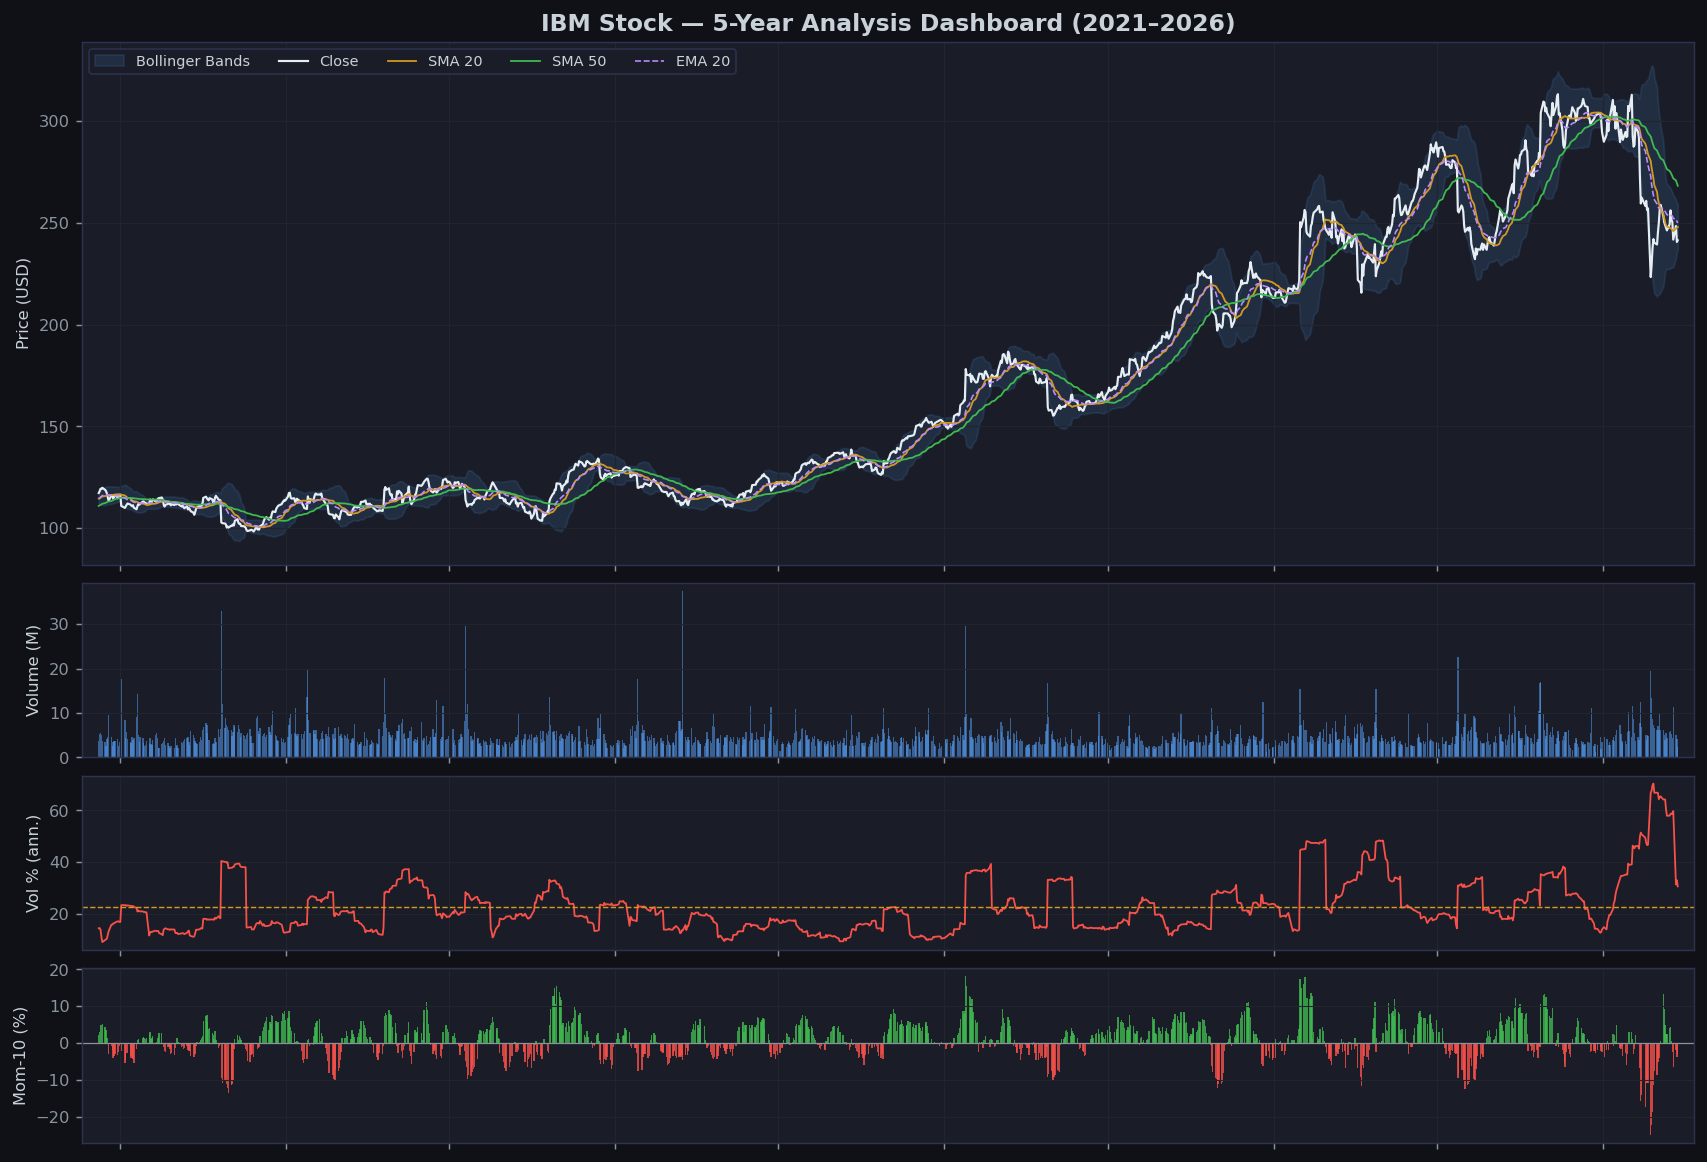

Trend range    : $99.68 – $305.13
Seasonal range : -6.3317 – 10.1025
Residual std   : 4.6524


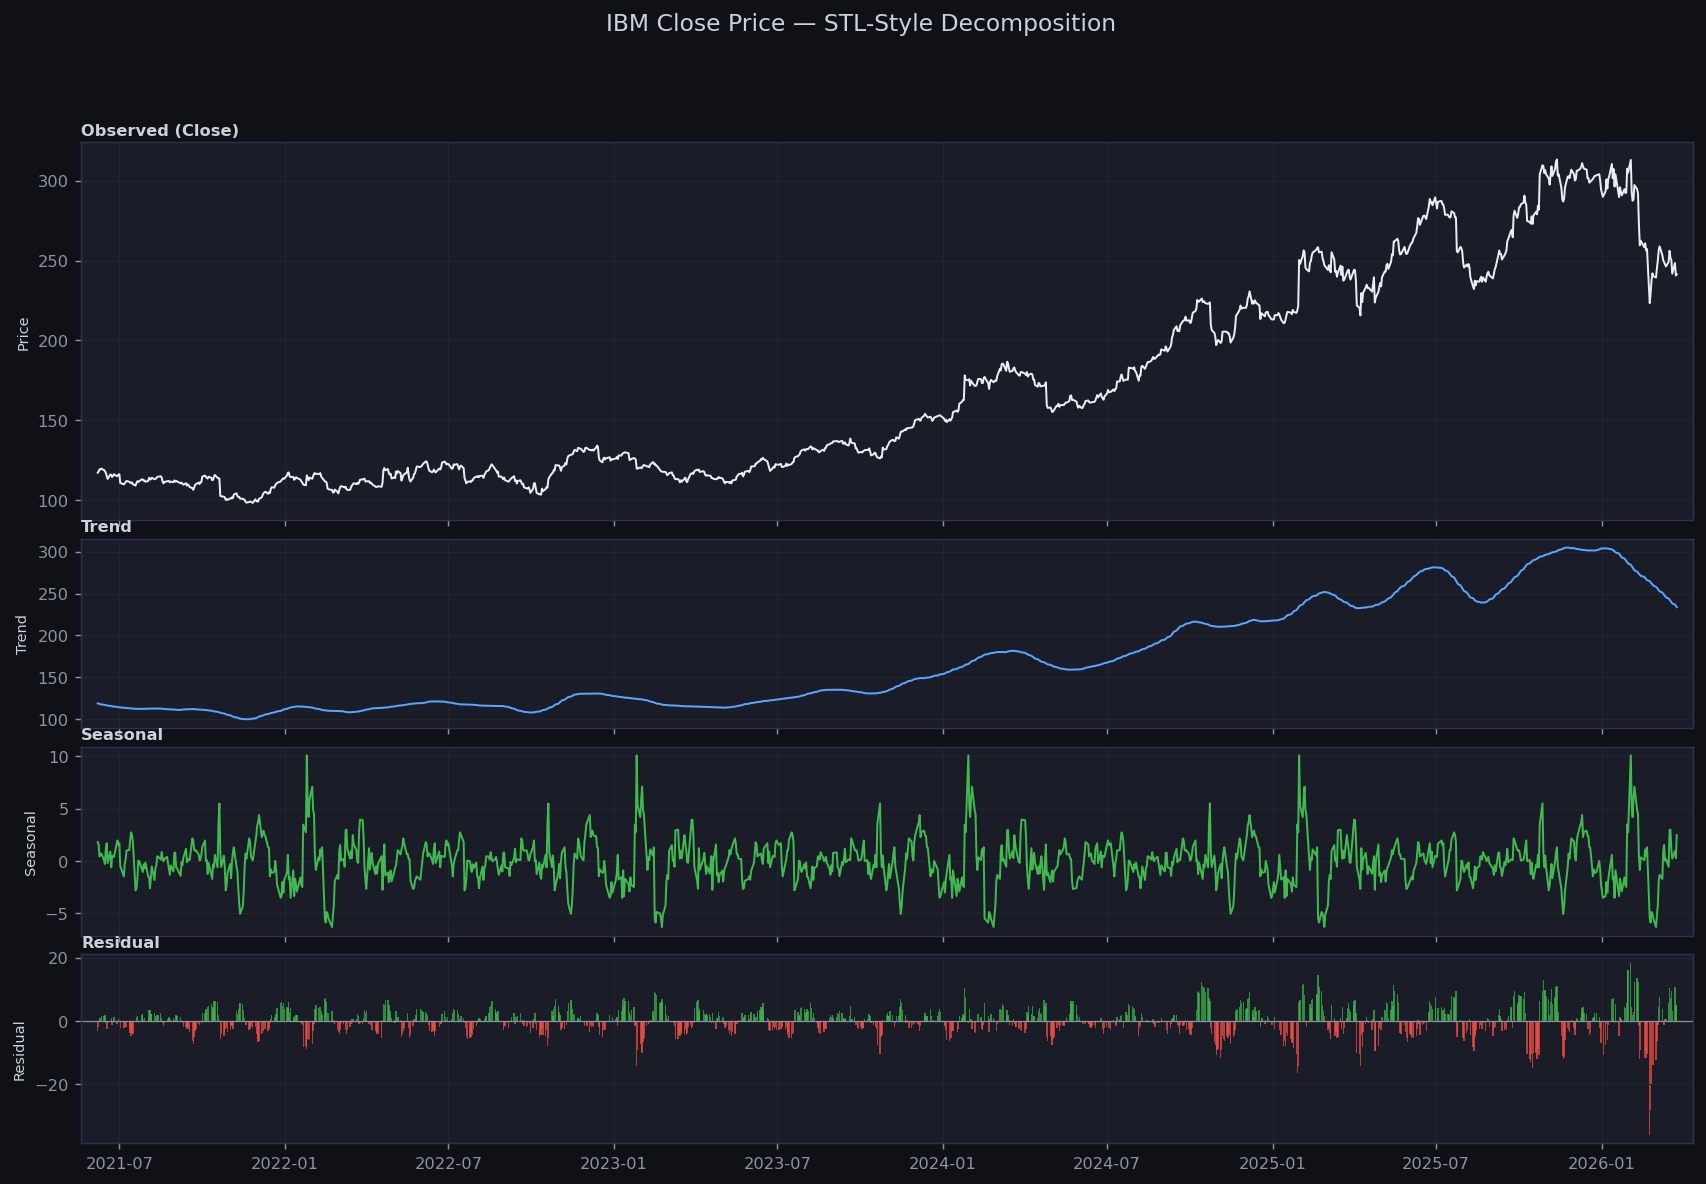

Total segments : 60
Window size    : 20 days
Feature matrix : (60, 12)
Computing DTW distance matrix …
  1770/1770 pairs — done        


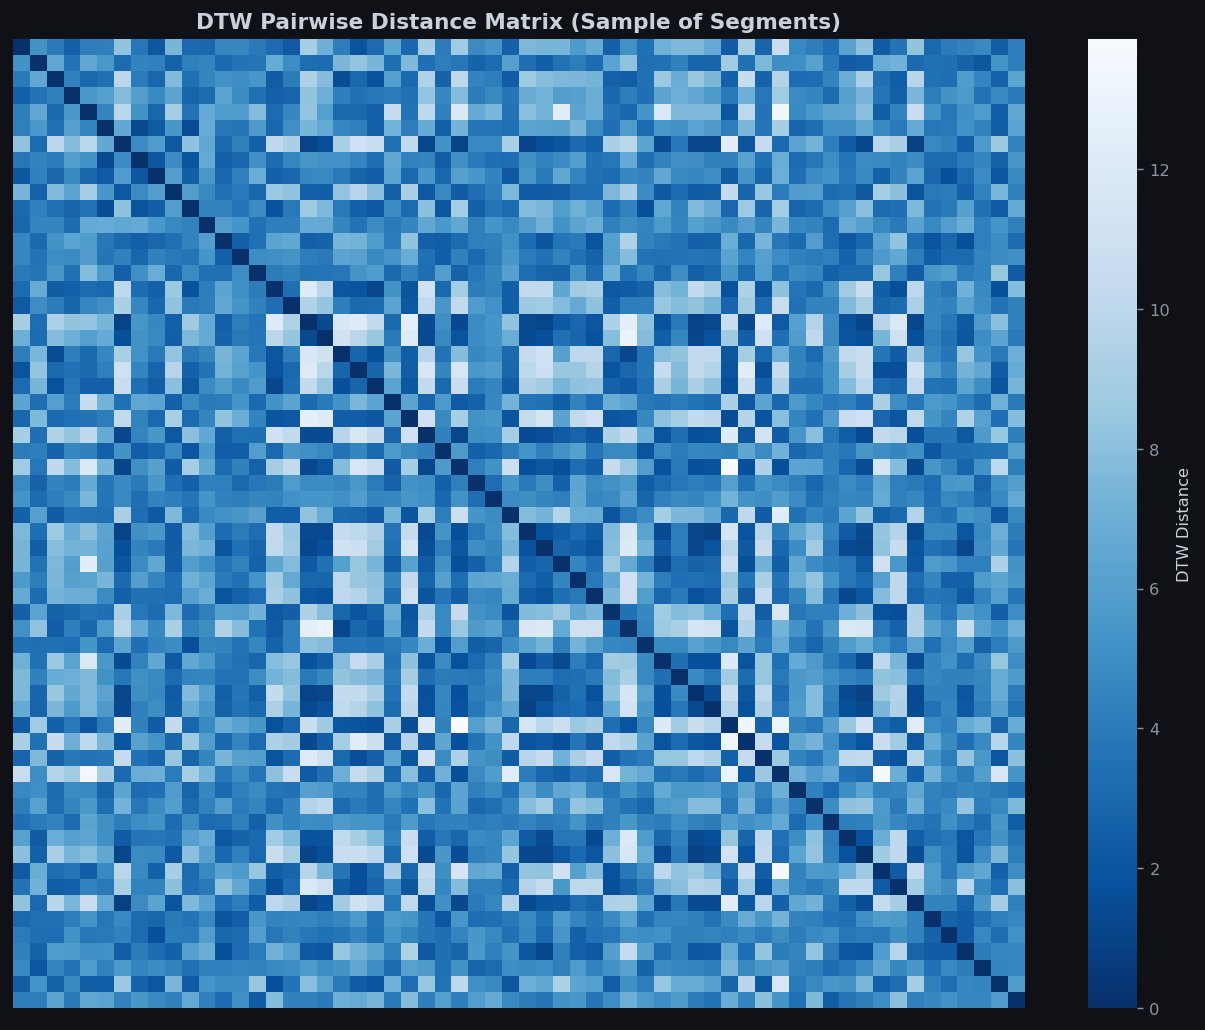

  K=2 | Inertia=   500.5 | Silhouette=0.3990 | DB=1.2691
  K=3 | Inertia=   381.6 | Silhouette=0.2358 | DB=1.2571
  K=4 | Inertia=   285.2 | Silhouette=0.2757 | DB=1.0477
  K=5 | Inertia=   243.9 | Silhouette=0.2272 | DB=1.1556
  K=6 | Inertia=   215.9 | Silhouette=0.2345 | DB=1.1467
  K=7 | Inertia=   200.2 | Silhouette=0.2061 | DB=1.1608
  K=8 | Inertia=   184.6 | Silhouette=0.2134 | DB=1.0445


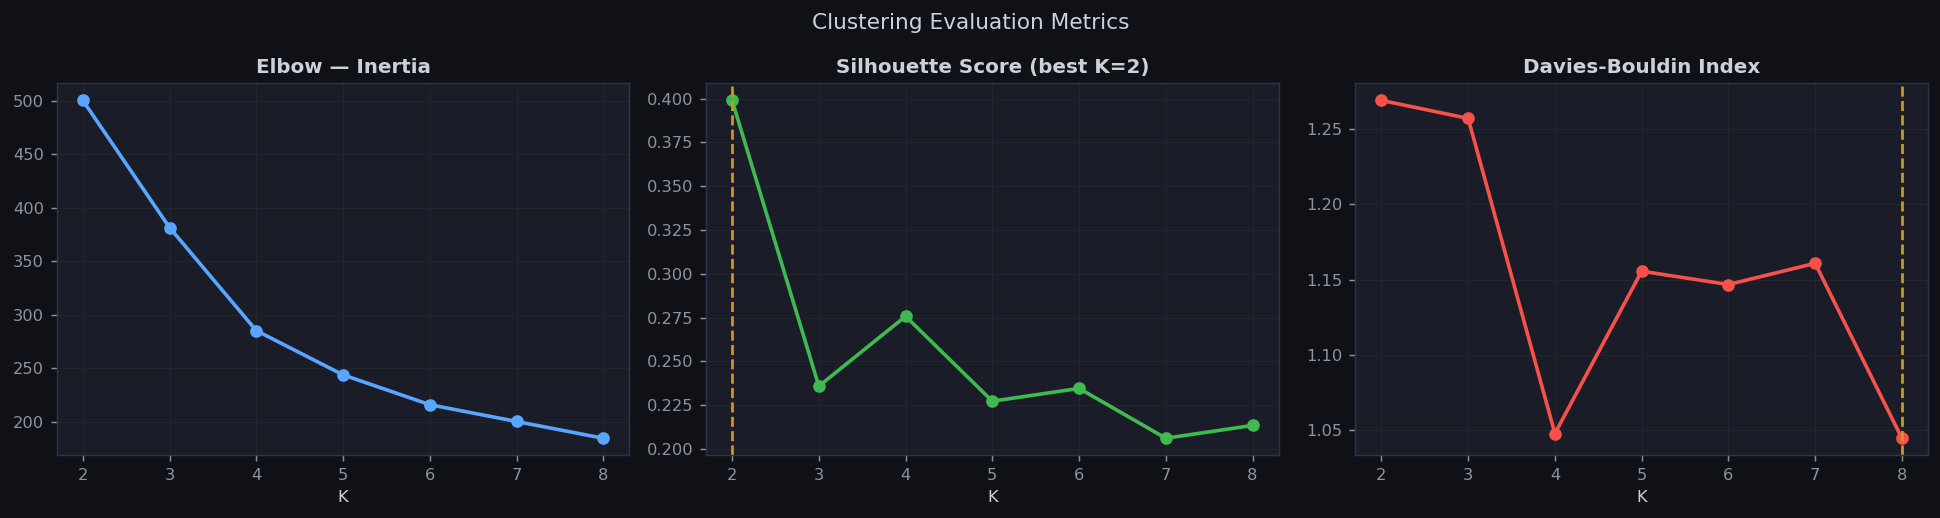


Optimal K = 2
K-Means      — Silhouette: 0.3990 | DB: 1.2691
Hierarchical — Silhouette: 0.5262 | DB: 0.6570
  Cluster 0 → 11 segments
  Cluster 1 → 49 segments


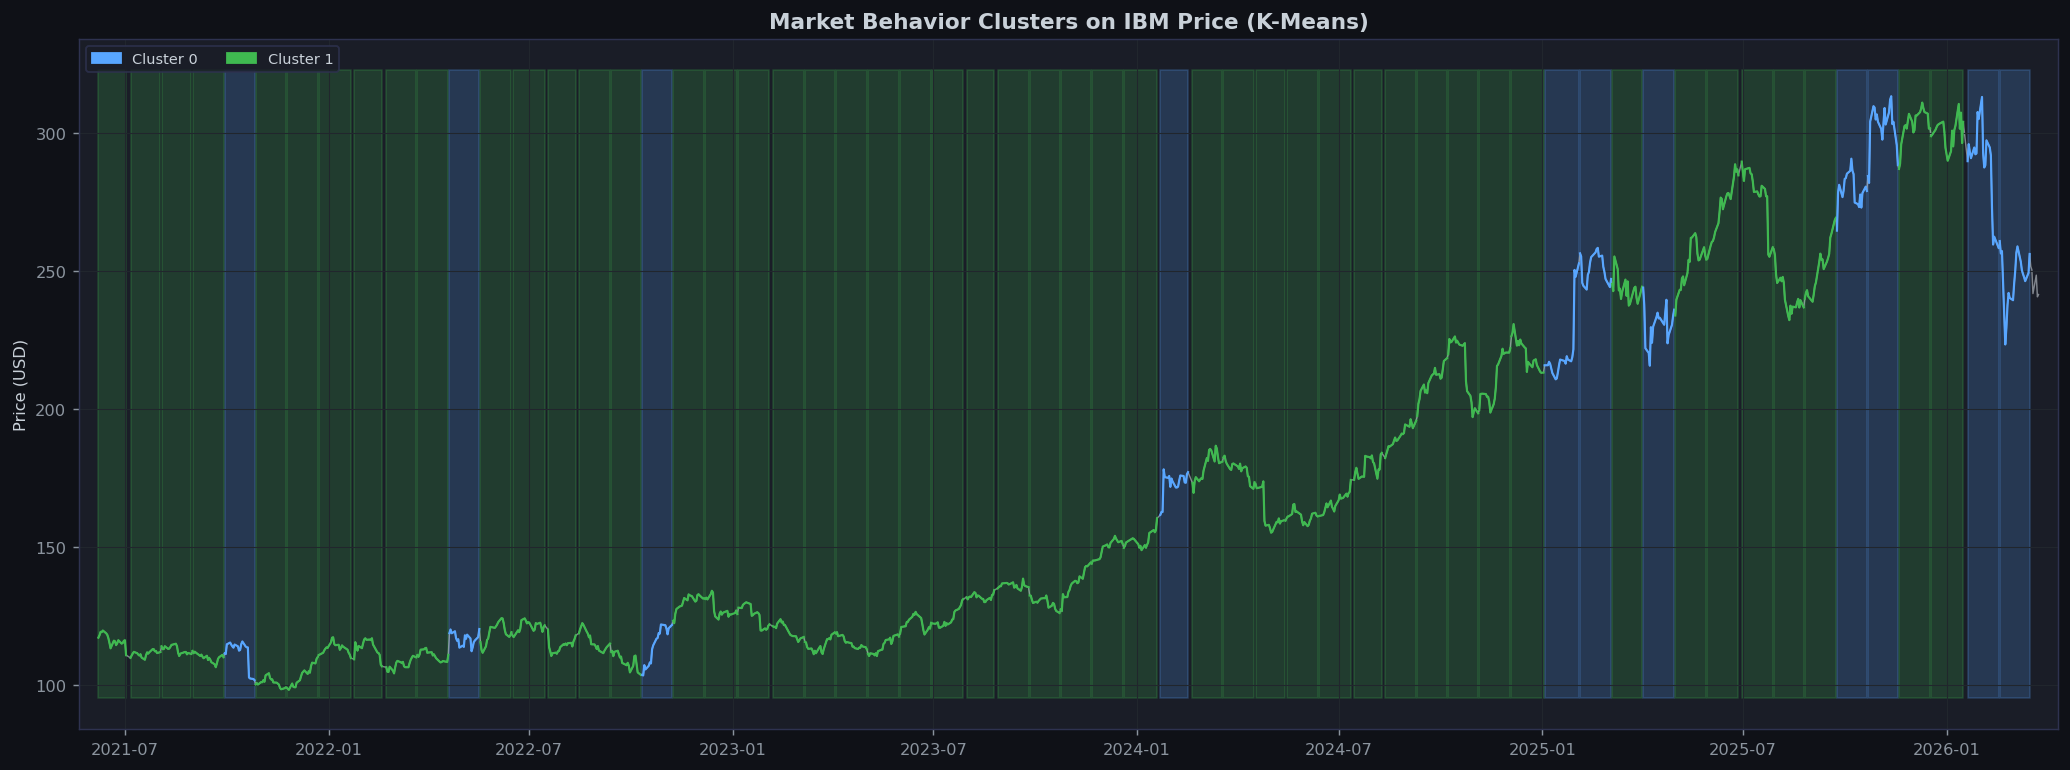

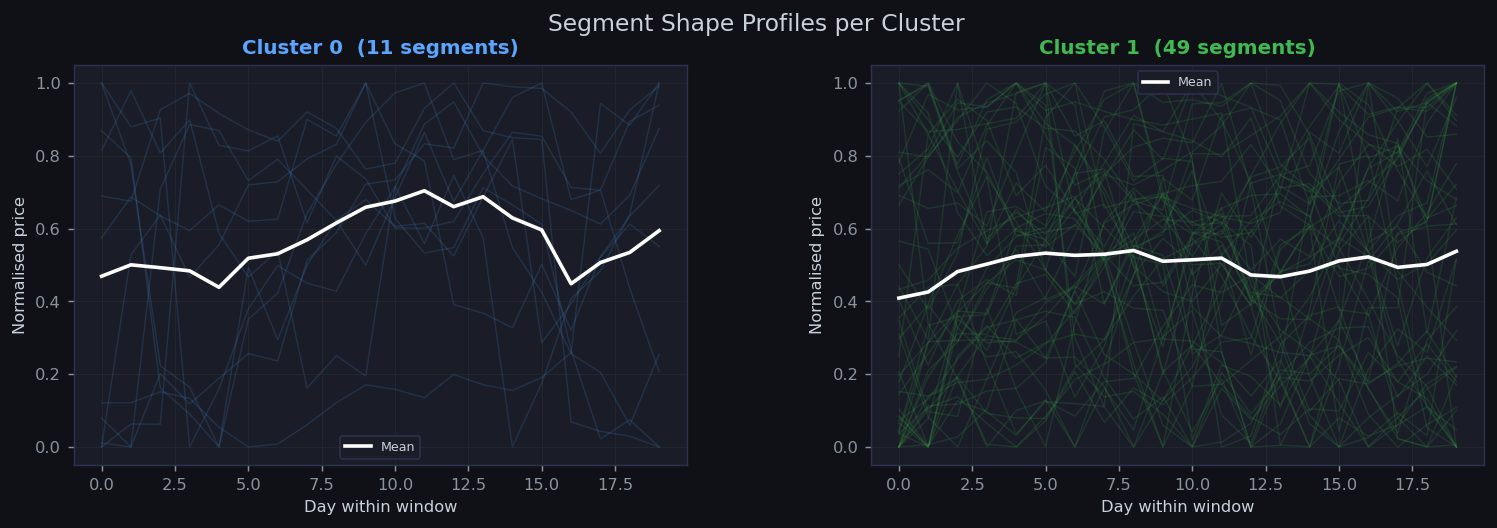

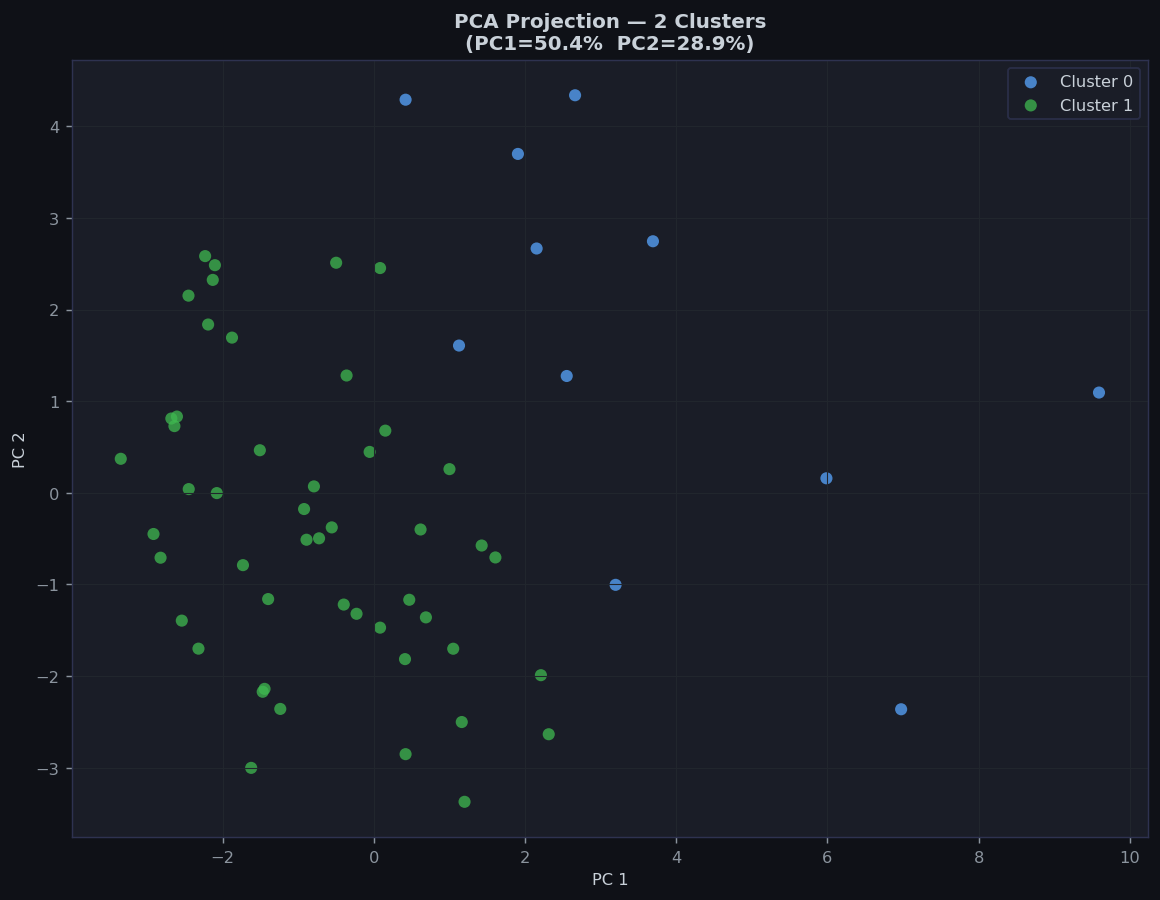

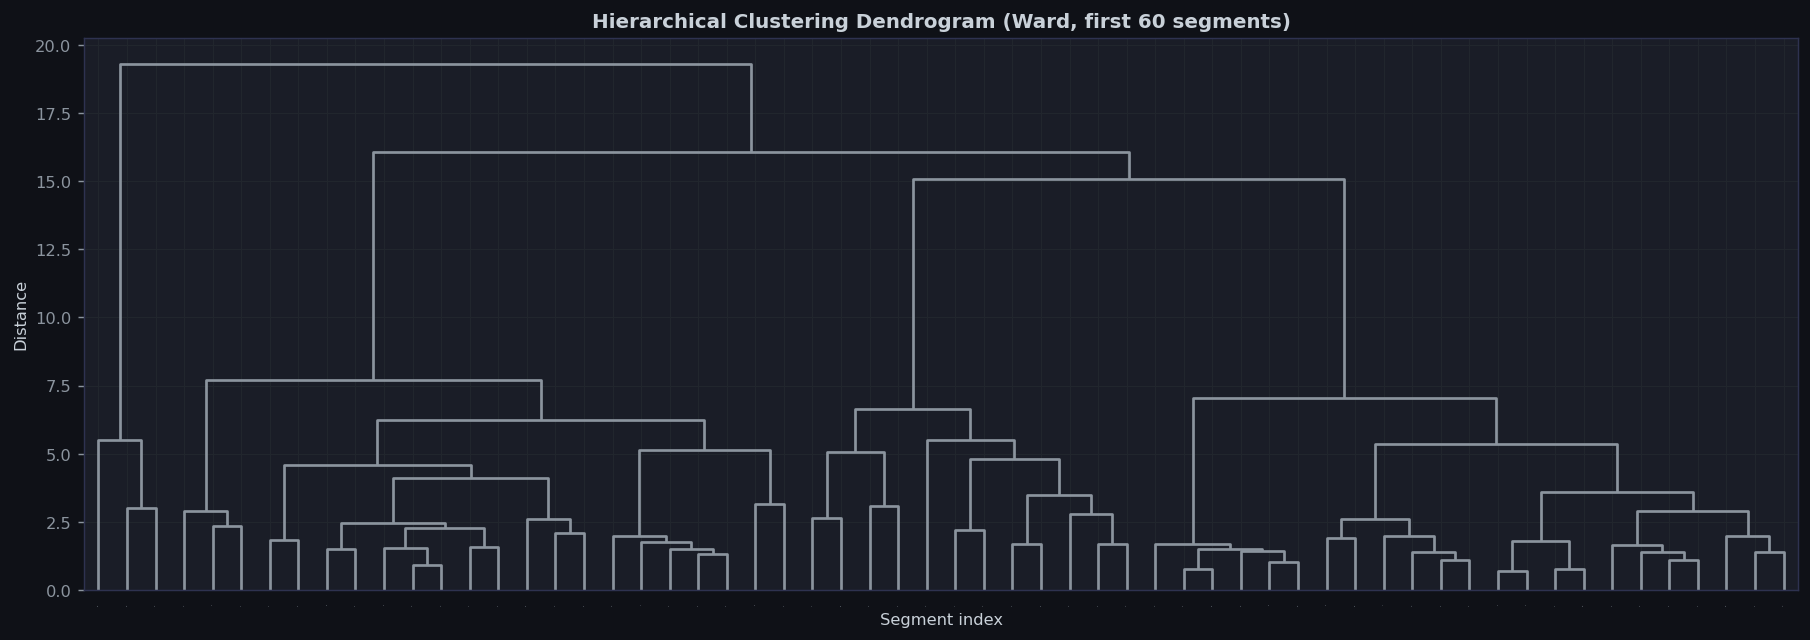

  Cluster 0: DTW = 2.2554  |  n_segs = 11
  Cluster 1: DTW = 1.0559  |  n_segs = 49


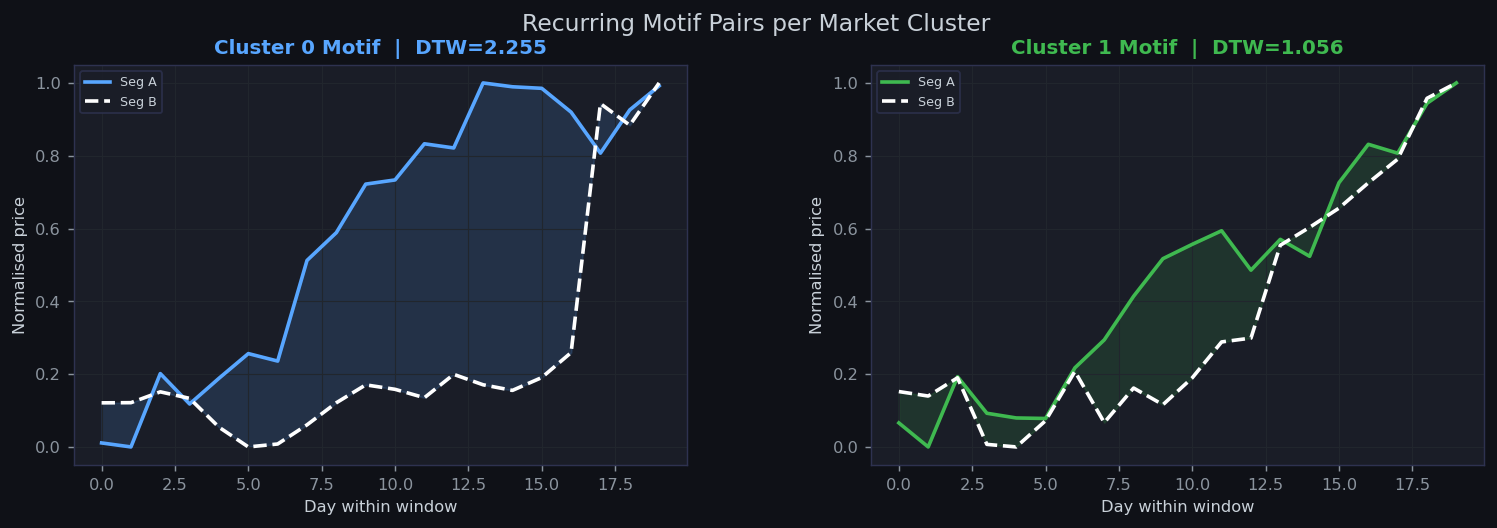

Z-score anomalies : 23
IQR anomalies     : 52
Isolation Forest  : 49
Strong (≥2 flags) : 40

Top anomalous dates:
  2026-02-03  |  Return=-6.71%  |  Vol=46.3%  |  Score=3
  2026-02-23  |  Return=-14.10%  |  Vol=66.8%  |  Score=3
  2026-02-12  |  Return=-4.99%  |  Vol=51.4%  |  Score=3
  2026-02-11  |  Return=-6.72%  |  Vol=49.8%  |  Score=3
  2025-04-24  |  Return=-6.81%  |  Vol=47.8%  |  Score=3
  2021-07-02  |  Return=-4.76%  |  Vol=23.3%  |  Score=2
  2022-01-25  |  Return=+5.50%  |  Vol=25.3%  |  Score=2
  2021-10-21  |  Return=-10.05%  |  Vol=40.4%  |  Score=2
  2024-04-25  |  Return=-8.61%  |  Vol=33.1%  |  Score=2
  2024-01-25  |  Return=+9.06%  |  Vol=34.8%  |  Score=2


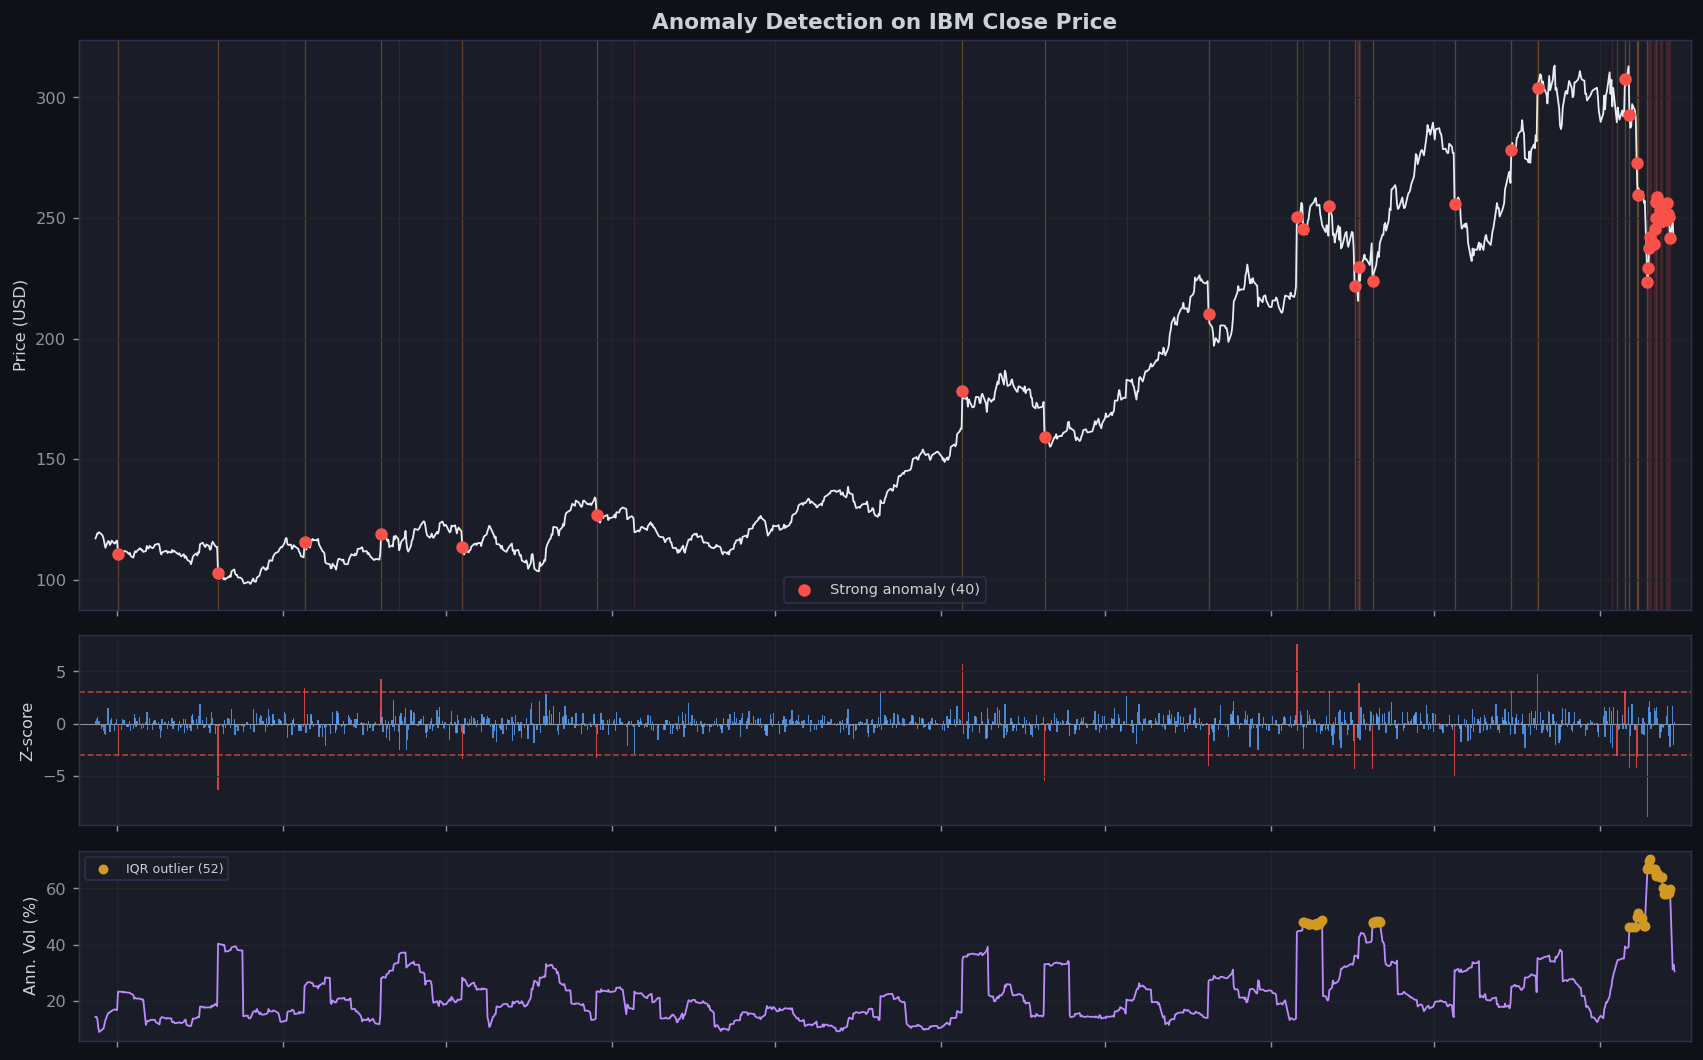

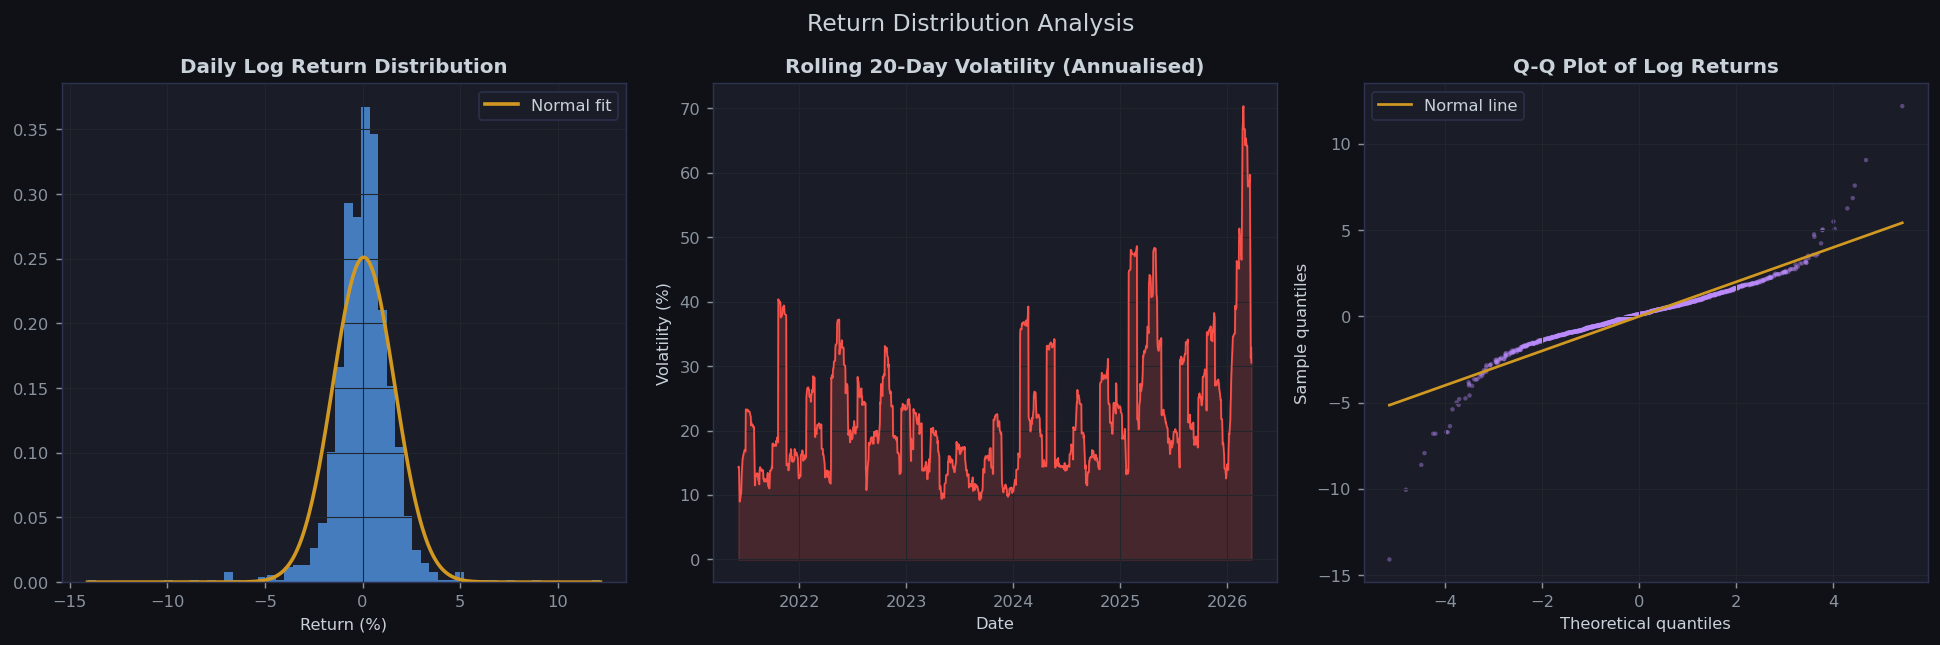

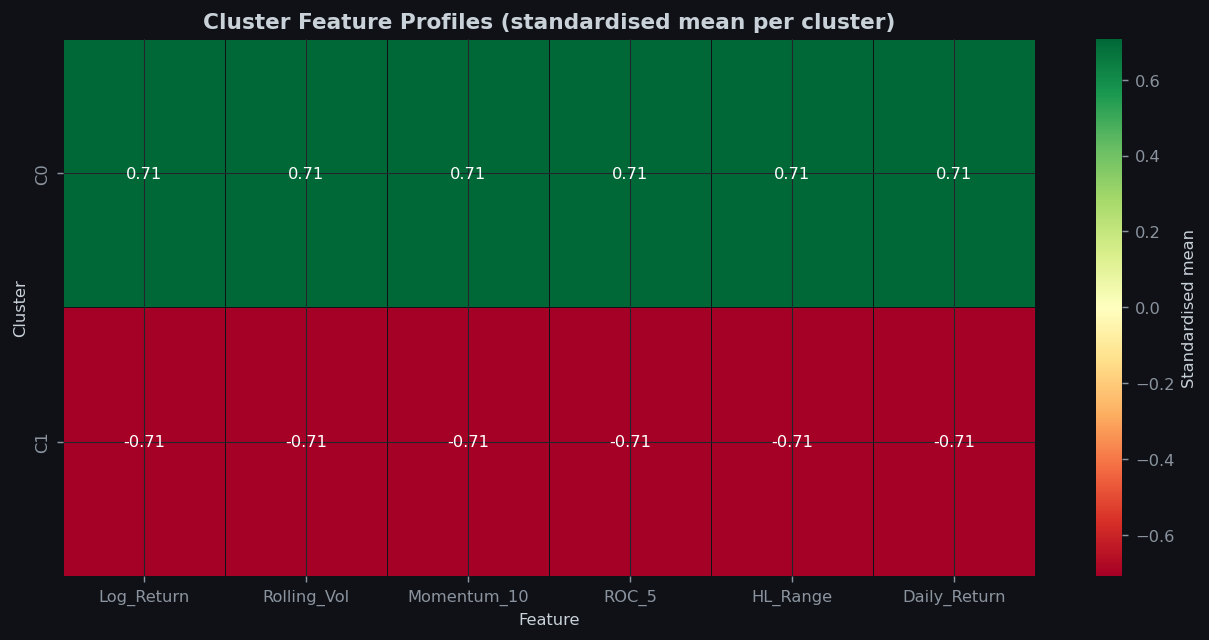


All done.


In [14]:
if __name__ == '__main__':

    FILE = 'IBM_5years_timeseries.csv'

    df = load_and_preprocess(FILE)
    plot_price_overview(df)

    trend, seasonal, residual = plot_decomposition(df)

    segments, close_windows, feature_matrix, seg_labels, seg_dates = \
        segment_series(df, window=20)

    dtw_matrix = compute_dtw_matrix(close_windows, sample_size=60)
    plot_dtw_heatmap(dtw_matrix)

    optimal_k = find_optimal_k(feature_matrix)
    km_labels, hc_labels = run_clustering(feature_matrix, optimal_k)

    plot_clusters_on_price(df, seg_dates, km_labels, optimal_k)
    plot_cluster_profiles(close_windows, km_labels, optimal_k)
    plot_pca_clusters(feature_matrix, km_labels, optimal_k)
    plot_dendrogram(feature_matrix)

    find_and_plot_motifs(close_windows, km_labels, optimal_k)

    anomaly_df = detect_and_plot_anomalies(df)

    plot_return_distribution(df)

    plot_cluster_heatmap(df, seg_dates, km_labels, optimal_k)

    print("\nAll done.")